# Notebook 20 — Foundation Model Embeddings (Chronos-T5)

**Phase 2b — Zero-shot embedding test**

A pre-trained foundation model (Amazon Chronos-T5-Small, 46 M params, trained on millions of unrelated time series) is used to embed all 12 datasets. No training on our data. No access to our feature choices.

**Prediction — written before running:**

If the taxonomy is real, Chronos should find a geometry similar to our hand-crafted features and the trained Conv AE, without any exposure to our data or our measurement choices.

Specific expectations:
- **Sunspot-COVID**: predict separation (5x+ expansion from feature-space) — Chronos should recognise the periodic cycle vs the burst shape
- **Temperature-sea_level**: uncertain — Chronos might contract them (both noisy trends, same underlying waveform) or separate them on speed-of-rise. The Conv AE contracted (0.17x); if Chronos agrees, the "noisy directional" 8th class is confirmed by three independent methods.
- **VIX-lynx_hare**: predict contraction stays (i.e. ratio near 1.0 or slightly lower) — both are irregular volatility, domain is surface-level
- **ENSO**: predict it stays near sunspot in Chronos space — Chronos has seen many oscillatory series and may cluster them together
- **Phase 1b overall**: predict they fill the visual gaps between clusters rather than landing in noise — continuous embedding space has no min_cluster_size floor

If Chronos recovers the same key features (temperature-sea_level contraction, sunspot-COVID separation), that is the strongest possible evidence: three independent methods (hand-crafted statistics, trained autoencoder, zero-shot foundation model) agree on the same shape geometry.

In [1]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from chronos import ChronosPipeline
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
ALL_COLS = TIMEDOM_COLS + SPECTRAL_COLS
TARGET_LEN = 64

print(f'PyTorch {torch.__version__}')
print(f'Target series length: {TARGET_LEN} points')

/home/skrsan/Documents/Projects/xworld/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


I0000 00:00:1774874019.619292  120800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774874019.619592  120800 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774874019.642659  120800 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774874020.142353  120800 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774874020.142533  120800 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


PyTorch 2.11.0+cu130
Target series length: 64 points


In [2]:
# ============================================================
# HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def spectral_features_fixed(series):
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)
    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0
    dom_freq = float(freqs[np.argmax(power)])
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    return {
        'dominant_freq':   dom_freq,
        'spectral_entropy': sp_ent,
        'power_low':  float(power_ac[:low_end].sum()  / total_ac),
        'power_mid':  float(power_ac[low_end:mid_end].sum() / total_ac),
        'power_high': float(power_ac[mid_end:].sum()  / total_ac),
    }


def extract_all_features(series):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta(arr),
    }
    return {**td, **spectral_features_fixed(arr)}


def resample_series(series, target_length=TARGET_LEN):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n = len(arr)
    if n == target_length:
        return arr
    x_old = np.linspace(0, 1, n)
    x_new = np.linspace(0, 1, target_length)
    return interp1d(x_old, arr, kind='linear')(x_new)


print('Helpers OK')

Helpers OK


In [3]:
# ============================================================
# DATASET 1: COVID (first + second wave)
# ============================================================
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records, raw_series = [], []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
            raw_series.append(resample_series(w))
df_covid_all = pd.DataFrame(records)
raw_covid = np.stack(raw_series)
print(df_covid_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_covid.shape}')

{'covid_second_wave': 209, 'covid_first_wave': 202}   raw shape: (411, 64)


In [4]:
# ============================================================
# DATASET 2: Sunspot cycles
# ============================================================
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80: cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records, raw_series = [], []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
    raw_series.append(resample_series(c))
df_ss_all = pd.DataFrame(records)
raw_ss = np.stack(raw_series)
print(f'Sunspot: {len(df_ss_all)} cycles  raw shape: {raw_ss.shape}')

Sunspot: 24 cycles  raw shape: (24, 64)


In [5]:
# ============================================================
# DATASET 3: Lynx-hare
# ============================================================
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records, raw_series = [], []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_lh_all = pd.DataFrame(records)
raw_lh = np.stack(raw_series)
print(f'Lynx-hare: {len(df_lh_all)}  raw shape: {raw_lh.shape}')

Lynx-hare: 26  raw shape: (26, 64)


In [6]:
# ============================================================
# DATASET 4: Keeling CO2 (seasonal + trend)
# ============================================================
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = (seg, 'keeling_seasonal')
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = (trend_vals[i:i+120], 'keeling_trend')
records, raw_series = [], []
for name, (s, ds) in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': ds, 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_k_all = pd.DataFrame(records)
raw_k = np.stack(raw_series)
print(df_k_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_k.shape}')

{'keeling_seasonal': 68, 'keeling_trend': 58}   raw shape: (126, 64)


In [7]:
# ============================================================
# DATASET 5: Global temperature anomaly
# ============================================================
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records, raw_series = [], []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_temp_all = pd.DataFrame(records)
raw_temp = np.stack(raw_series)
print(f'Temperature: {len(df_temp_all)}  raw shape: {raw_temp.shape}')

Temperature: 31  raw shape: (31, 64)


In [8]:
# ============================================================
# DATASET 6: ECG (requires ECGFiveDays.zip in data/raw/)
# ============================================================
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

ts_files = list(dest_dir.rglob('*.ts'))
all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
records, raw_series = [], []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_ecg_all = pd.DataFrame(records)
raw_ecg = np.stack(raw_series)
print(f'ECG: {len(df_ecg_all)}  kurtosis={df_ecg_all["kurtosis"].mean():.2f}  raw shape: {raw_ecg.shape}')

Cached: ../data/raw/ECGFiveDays


ECG: 884  kurtosis=15.17  raw shape: (884, 64)


In [9]:
# ============================================================
# DATASET 7: Streamflow (USGS)
# ============================================================
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',    '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=45) as resp:
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

print(f'Fetching {len(STATIONS)} USGS stations...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')

records, raw_series = [], []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
    raw_series.append(resample_series(log_flow))
df_sf_all = pd.DataFrame(records)
raw_sf = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Streamflow: {len(df_sf_all)}  raw shape: {raw_sf.shape}')

Fetching 25 USGS stations...


  OK mohawk_ny


  OK delaware_ny


  OK choptank_md


  OK neuse_nc


...

  OK columbia_or


  OK willamette_or


  OK cannonball_nd


  OK escatawpa_ms


  OK nashua_ma
Streamflow: 24  raw shape: (24, 64)


In [10]:
# ============================================================
# DATASET 8: Sea level (Phase 1b)
# ============================================================
dest = RAW_DIR / 'sea_level_nasa.csv'
if dest.exists(): dest.unlink()
urls = [
    'https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelRise/slr/slr_sla_gbl_keep_all_66.csv',
    'https://sealevel.colorado.edu/files/current/sl_ns_global.txt',
]
content = None
for url in urls:
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        if b'<!' not in r.content[:20]: content = r.content; print(f'OK: {url[:50]}'); break
    except Exception as e: print(f'  {url[:40]}: {e}')
if content is None: raise RuntimeError('Sea level: all URLs failed')
dest.write_bytes(content)
df_sl = pd.read_csv(dest, comment='#')
mission_cols = [c for c in df_sl.columns if c != 'year']
df_sl['gmsl'] = df_sl[mission_cols].mean(axis=1, skipna=True)
df_sl = df_sl[['year','gmsl']].dropna().rename(columns={'year':'year_frac'}).sort_values('year_frac').reset_index(drop=True)
values_sl = df_sl['gmsl'].values
year_fracs = df_sl['year_frac'].values
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_sl)-window, step):
    s = values_sl[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'sl_{int(year_fracs[i])}','dataset':'sea_level','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_sl_all = pd.DataFrame(records)
raw_sl = np.stack(raw_series)
print(f'Sea level: {len(df_sl_all)}  raw shape: {raw_sl.shape}')

OK: https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelR
Sea level: 120  raw shape: (120, 64)


In [11]:
# ============================================================
# DATASET 9: ENSO ONI (Phase 1b)
# ============================================================
dest = RAW_DIR / 'oni_enso.txt'
if not dest.exists():
    r = requests.get('https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',
                     headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    r.raise_for_status(); dest.write_bytes(r.content)
rows = []
with open(dest) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4 and not line.strip().startswith('SEAS'):
            try: rows.append({'year': int(parts[1]), 'oni': float(parts[3])})
            except (ValueError, IndexError): pass
df_oni = pd.DataFrame(rows).dropna()
values_oni = df_oni['oni'].values
window, step = 36, 6
records, raw_series = [], []
for i in range(0, len(values_oni)-window, step):
    s = values_oni[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'oni_{df_oni["year"].iloc[i]}','dataset':'enso_oni','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_oni_all = pd.DataFrame(records)
raw_oni = np.stack(raw_series)
print(f'ENSO ONI: {len(df_oni_all)}  raw shape: {raw_oni.shape}')

ENSO ONI: 147  raw shape: (147, 64)


In [12]:
# ============================================================
# DATASET 10: VIX (Phase 1b)
# ============================================================
dest = RAW_DIR / 'vix_fred.csv'
if dest.exists(): dest.unlink()
for name, url in [('cboe-cdn','https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv'),
                   ('cboe-www','https://www.cboe.com/publish/ScheduledTask/MktData/datahouse/vixcurrent.csv')]:
    try:
        r = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}, timeout=60)
        r.raise_for_status()
        if b'<!DOCTYPE' not in r.content[:200] and len(r.content) > 100:
            dest.write_bytes(r.content); print(f'VIX OK ({name})'); break
    except Exception as e: print(f'  {name}: {e}')
else: raise RuntimeError('All VIX sources failed')
df_vix = pd.read_csv(dest, parse_dates=['DATE'], dayfirst=False)
df_vix = df_vix[['DATE','CLOSE']].rename(columns={'DATE':'date','CLOSE':'vix'}).dropna()
df_vix = df_vix.set_index('date').resample('MS').mean().dropna().reset_index()
values_vix = df_vix['vix'].values
window, step = 24, 3
records, raw_series = [], []
for i in range(0, len(values_vix)-window, step):
    s = values_vix[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'vix_{df_vix["date"].iloc[i].year}_{i}','dataset':'vix','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_vix_all = pd.DataFrame(records)
raw_vix = np.stack(raw_series)
print(f'VIX: {len(df_vix_all)}  raw shape: {raw_vix.shape}')

VIX OK (cboe-cdn)
VIX: 137  raw shape: (137, 64)


In [13]:
# ============================================================
# COMBINE — feature DataFrame + raw series matrix (aligned)
# ============================================================
df_all = pd.concat([
    df_covid_all, df_ss_all, df_lh_all, df_k_all,
    df_temp_all, df_ecg_all, df_sf_all,
    df_sl_all, df_oni_all, df_vix_all
], ignore_index=True)

X_raw_all = np.concatenate([
    raw_covid, raw_ss, raw_lh, raw_k,
    raw_temp, raw_ecg, raw_sf,
    raw_sl, raw_oni, raw_vix
], axis=0)

# Drop NaN feature rows (keep aligned)
valid_mask = df_all[ALL_COLS].notna().all(axis=1).values
df_all     = df_all[valid_mask].reset_index(drop=True)
X_raw_all  = X_raw_all[valid_mask]

DATASETS = sorted(df_all['dataset'].unique())
ORIG_9   = ['covid_first_wave','covid_second_wave','ecg','keeling_seasonal',
             'keeling_trend','lynx_hare','streamflow','sunspot_cycle','temperature']
PHASE1B  = ['enso_oni','sea_level','vix']

palette   = sns.color_palette('tab10', len(DATASETS))
ds_color  = {ds: palette[i] for i, ds in enumerate(DATASETS)}
ds_labels = df_all['dataset'].values

print(f'Total instances:  {len(df_all)}')
print(f'Raw series shape: {X_raw_all.shape}')
assert len(df_all) == len(X_raw_all), 'ALIGNMENT ERROR'
print('Alignment check: OK')
print()
for ds in DATASETS:
    tag = '(1b)' if ds in PHASE1B else '    '
    print(f'  {tag} {ds:25s}: {(df_all["dataset"]==ds).sum()}')

Total instances:  1930
Raw series shape: (1930, 64)
Alignment check: OK

       covid_first_wave         : 202
       covid_second_wave        : 209
       ecg                      : 884
  (1b) enso_oni                 : 147
       keeling_seasonal         : 68
       keeling_trend            : 58
       lynx_hare                : 26
  (1b) sea_level                : 120
       streamflow               : 24
       sunspot_cycle            : 24
       temperature              : 31
  (1b) vix                      : 137


In [14]:
# ============================================================
# LOAD CHRONOS — chronos-t5-small (46 M params, 512-dim)
# Zero-shot: model has never seen our data.
# We extract mean-pooled T5 encoder hidden states.
# ============================================================
print('Loading Chronos-T5-Small (downloads ~200 MB on first run)...')
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map='cpu',
    dtype=torch.float32,
)
encoder = pipeline.model.model.encoder
encoder.eval()
print(f'Encoder loaded. Hidden dim: {encoder.config.d_model}')

def get_chronos_embedding(series_array):
    """
    Extract mean-pooled T5 encoder embeddings for a batch of series.
    series_array: (n, T) float32 numpy array of z-scored, resampled series.
    Returns: (n, D) numpy array of embeddings.
    """
    embeddings = []
    for i, s in enumerate(series_array):
        ts = torch.tensor(s, dtype=torch.float32).unsqueeze(0)  # (1, T)
        token_ids, attention_mask, _ = pipeline.tokenizer.context_input_transform(ts)
        with torch.no_grad():
            enc_out = encoder(input_ids=token_ids, attention_mask=attention_mask)
        h = enc_out.last_hidden_state  # (1, seq_len, D)
        # Masked mean-pool (mask is all 1s since series are clean, but keep it correct)
        mask = attention_mask.unsqueeze(-1).float()
        emb = (h * mask).sum(dim=1) / mask.sum(dim=1)  # (1, D)
        embeddings.append(emb.squeeze(0).numpy())
        if (i+1) % 200 == 0:
            print(f'  Embedded {i+1}/{len(series_array)}...')
    return np.array(embeddings, dtype=np.float32)

print(f'Extracting Chronos embeddings for {len(X_raw_all)} series...')
Z_chronos = get_chronos_embedding(X_raw_all)
print(f'Chronos embedding matrix: {Z_chronos.shape}  (n x D)')
print('Done.')

Loading Chronos-T5-Small (downloads ~200 MB on first run)...


Encoder loaded. Hidden dim: 512
Extracting Chronos embeddings for 1930 series...


  Embedded 200/1930...


  Embedded 400/1930...


  Embedded 600/1930...


...

  Embedded 1200/1930...


  Embedded 1400/1930...


  Embedded 1600/1930...


  Embedded 1800/1930...


Chronos embedding matrix: (1930, 512)  (n x D)
Done.


Feature-space UMAP...


Chronos latent UMAP...


Plotting...


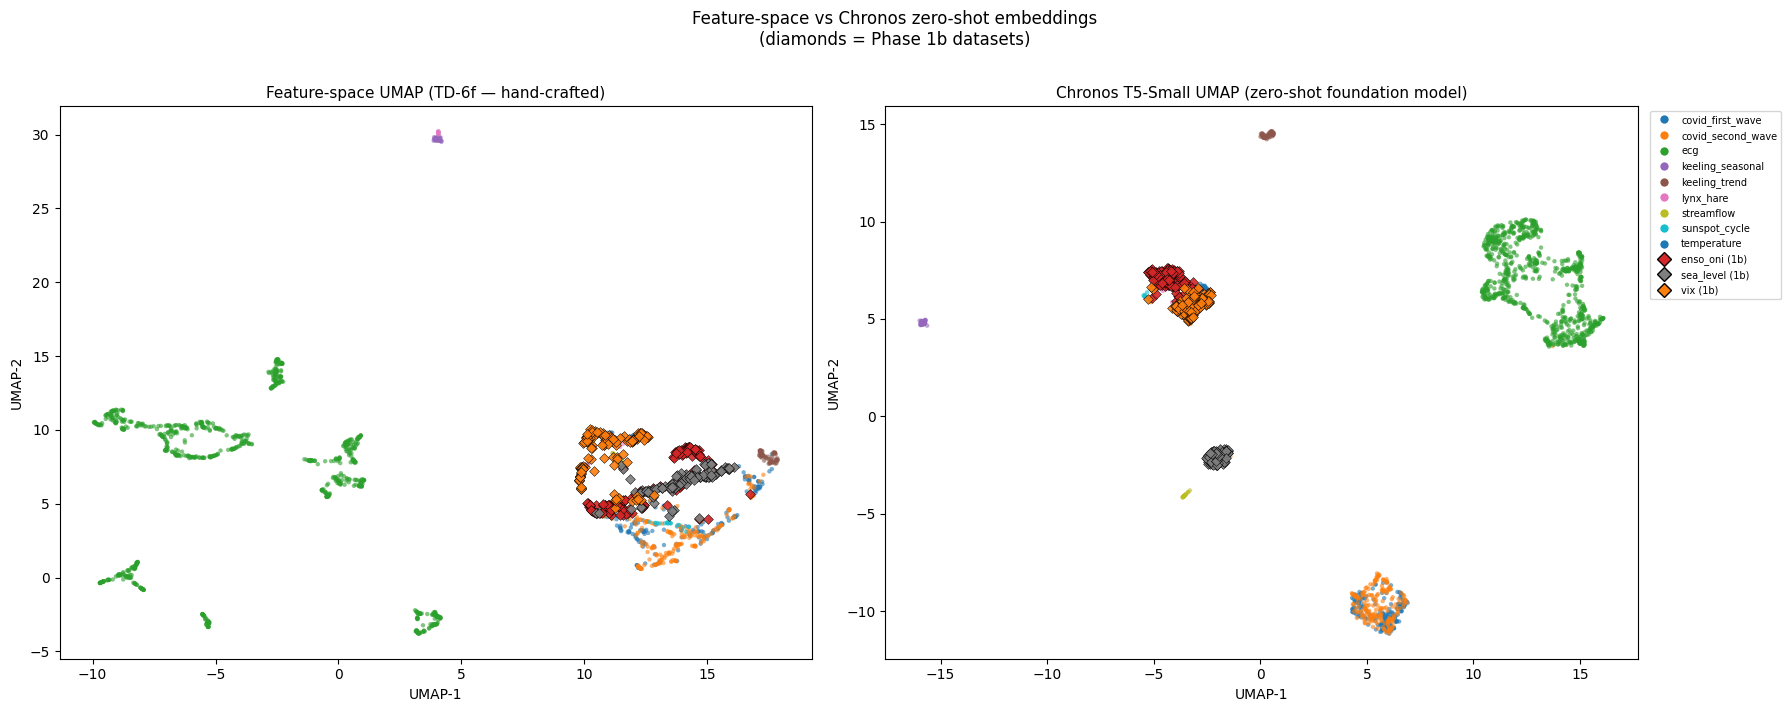


Key visual question: Do Phase 1b diamonds sit in gaps between clusters, or remain isolated?
Do temperature and sea_level sit near each other in both panels?


In [15]:
# ============================================================
# UMAP comparison: Feature-space  |  Chronos embedding
# ============================================================
print('Feature-space UMAP...')
X_feat = StandardScaler().fit_transform(df_all[TIMEDOM_COLS].values)
reducer_feat = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_feat = reducer_feat.fit_transform(X_feat)

print('Chronos latent UMAP...')
reducer_ch = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_ch = reducer_ch.fit_transform(Z_chronos)

print('Plotting...')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, emb, title in [
    (axes[0], emb_feat, 'Feature-space UMAP (TD-6f — hand-crafted)'),
    (axes[1], emb_ch,   'Chronos T5-Small UMAP (zero-shot foundation model)'),
]:
    for ds in ORIG_9:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=10,
                   alpha=0.6, label=ds, edgecolors='none')
    for ds in PHASE1B:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=25,
                   alpha=0.9, marker='D', edgecolors='k', linewidths=0.4, label=f'{ds} (1b)')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds],
                       markersize=7, label=ds) for ds in ORIG_9 if ds in DATASETS]
handles += [plt.Line2D([0],[0], marker='D', color='w', markerfacecolor=ds_color[ds],
                        markersize=7, markeredgecolor='k', label=f'{ds} (1b)')
            for ds in PHASE1B if ds in DATASETS]
axes[1].legend(handles=handles, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
plt.suptitle('Feature-space vs Chronos zero-shot embeddings\n(diamonds = Phase 1b datasets)', y=1.01)
plt.tight_layout()
plt.show()

print('\nKey visual question: Do Phase 1b diamonds sit in gaps between clusters, or remain isolated?')
print('Do temperature and sea_level sit near each other in both panels?')

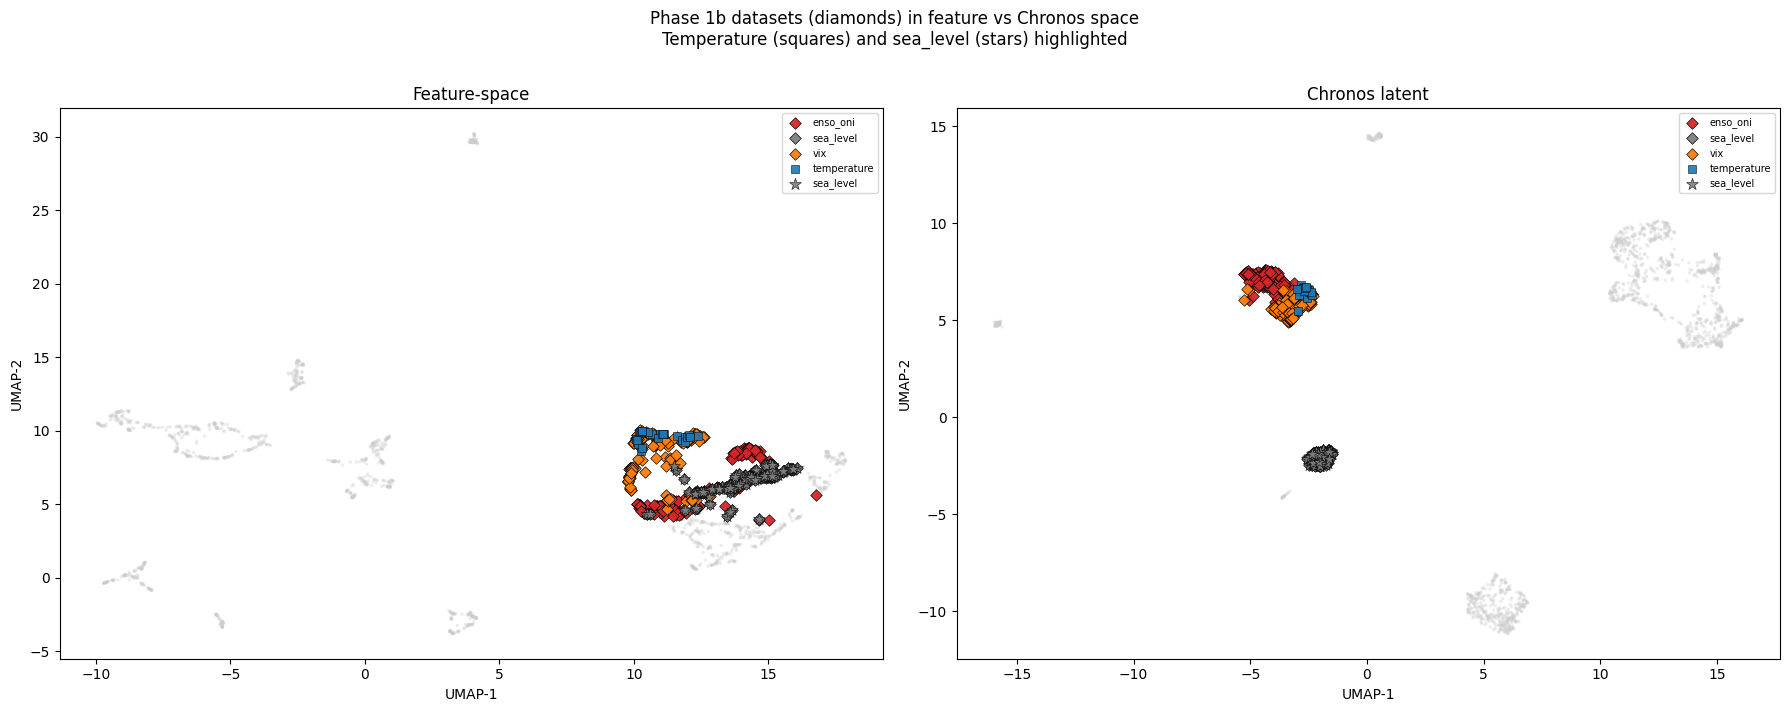

In [16]:
# ============================================================
# KEY QUESTION 1: Where do Phase 1b datasets sit in Chronos space?
# Do they fill the gaps, or remain structurally isolated?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, emb, title in [
    (axes[0], emb_feat, 'Feature-space'),
    (axes[1], emb_ch,   'Chronos latent'),
]:
    # Background: original 9 (greyed)
    for ds in ORIG_9:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c='#cccccc', s=6, alpha=0.35, edgecolors='none')

    # Phase 1b: coloured prominently
    for ds in PHASE1B:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=35,
                   alpha=0.95, marker='D', edgecolors='k', linewidths=0.5, label=ds)

    # Temperature and sea_level as special focus
    for ds, marker in [('temperature','s'), ('sea_level','*')]:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=40 if marker=='s' else 80,
                   alpha=0.9, marker=marker, edgecolors='k', linewidths=0.4, label=ds)

    ax.set_title(title); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Phase 1b datasets (diamonds) in feature vs Chronos space\n'
             'Temperature (squares) and sea_level (stars) highlighted', y=1.01)
plt.tight_layout()
plt.show()

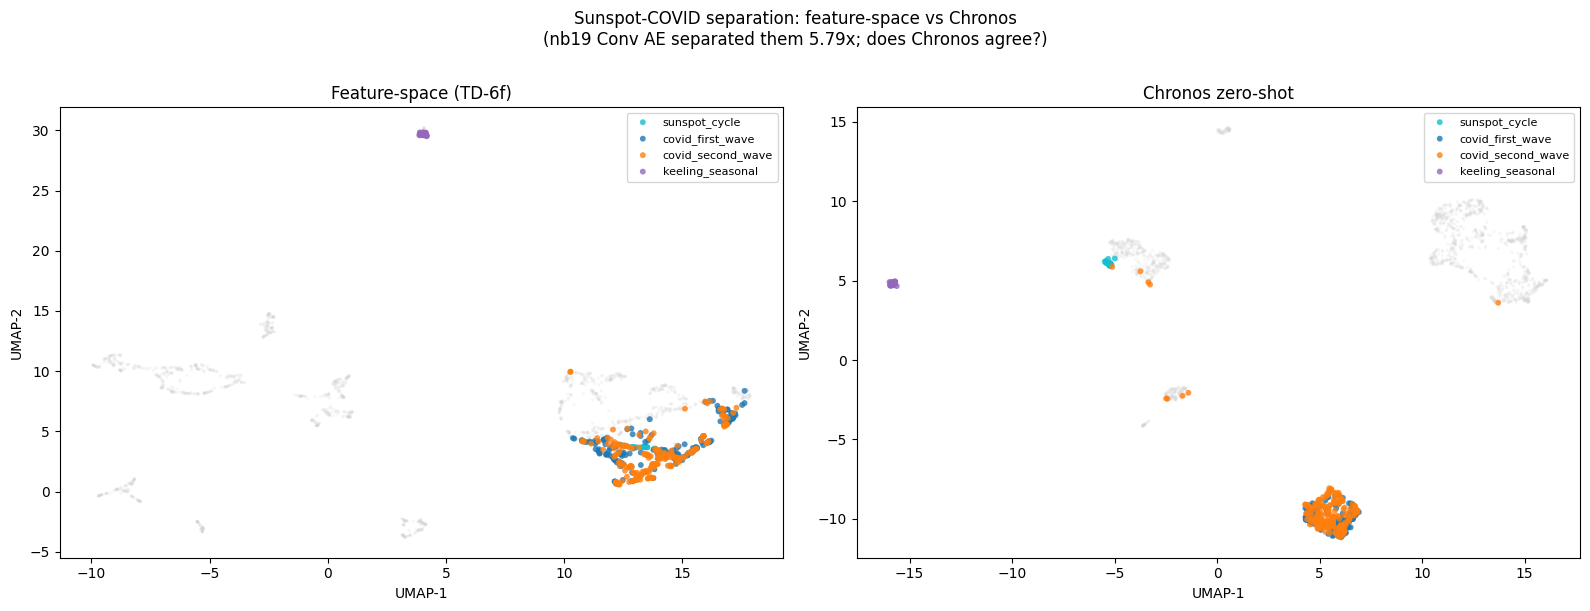

In [17]:
# ============================================================
# KEY QUESTION 2: Sunspot-COVID separation in Chronos space
# nb19 Conv AE: 5.79x expansion
# Does Chronos independently confirm this separation?
# ============================================================
highlight_ds = ['sunspot_cycle', 'covid_first_wave', 'covid_second_wave', 'keeling_seasonal']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, emb, title in [
    (axes[0], emb_feat, 'Feature-space (TD-6f)'),
    (axes[1], emb_ch,   'Chronos zero-shot'),
]:
    others = ~np.isin(ds_labels, highlight_ds)
    ax.scatter(emb[others,0], emb[others,1], c='lightgrey', s=5, alpha=0.2, edgecolors='none')
    for ds in highlight_ds:
        if ds not in DATASETS: continue
        mask = ds_labels == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[ds_color[ds]], s=18,
                   alpha=0.8, label=ds, edgecolors='none')
    ax.set_title(title); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=8)

plt.suptitle('Sunspot-COVID separation: feature-space vs Chronos\n'
             '(nb19 Conv AE separated them 5.79x; does Chronos agree?)', y=1.01)
plt.tight_layout()
plt.show()

ECG instances:     884
Chronos clusters:  3  (noise: 676)
ARI vs UCR labels: 0.742


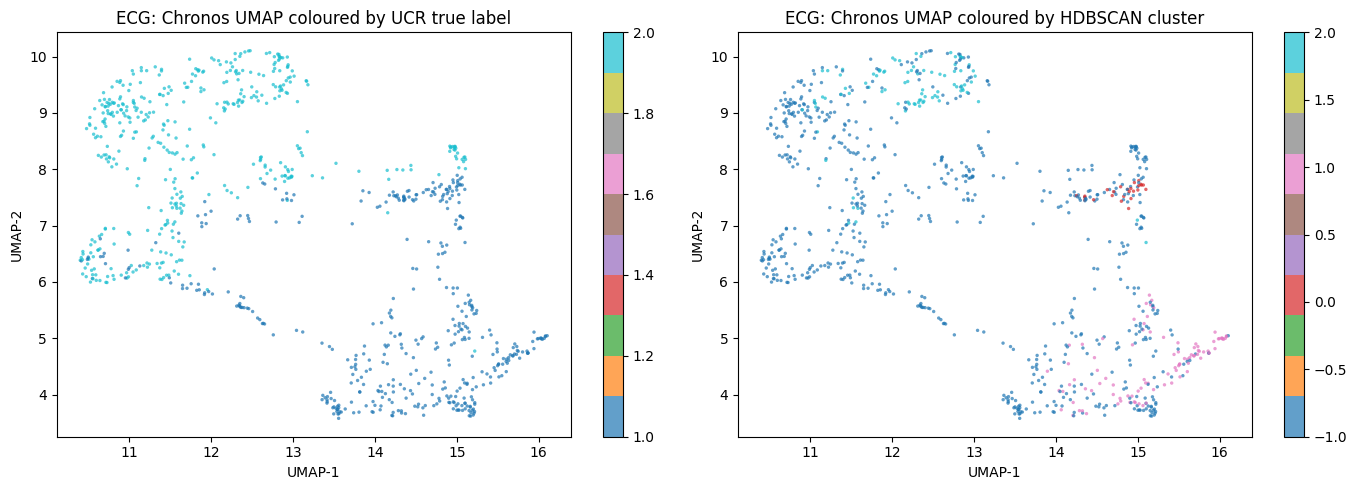

In [18]:
# ============================================================
# KEY QUESTION 3: ECG sub-structure in Chronos space
# Does Chronos split ECG into class-1 vs class-2?
# ============================================================
mask_ecg   = ds_labels == 'ecg'
Z_ecg_ch   = Z_chronos[mask_ecg]
emb_ecg_ch = emb_ch[mask_ecg]

# ECG true labels from UCR file naming: country = 'ecg_i_c{label}'
ecg_true = df_all.loc[mask_ecg, 'country'].str.extract(r'c(\d+)')[0].astype(int).values

# HDBSCAN on Chronos ECG embeddings
ecg_cl = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5).fit_predict(Z_ecg_ch)
n_ecg_cl = len(set(ecg_cl)) - (1 if -1 in ecg_cl else 0)
ecg_noise = (ecg_cl == -1).sum()

print(f'ECG instances:     {mask_ecg.sum()}')
print(f'Chronos clusters:  {n_ecg_cl}  (noise: {ecg_noise})')

if n_ecg_cl >= 2 and len(set(ecg_true)) >= 2:
    ari = adjusted_rand_score(ecg_true[ecg_cl >= 0], ecg_cl[ecg_cl >= 0])
    print(f'ARI vs UCR labels: {ari:.3f}')
else:
    print('Cannot compute ARI — insufficient clusters or labels')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], ecg_true, 'ECG: Chronos UMAP coloured by UCR true label'),
    (axes[1], ecg_cl,   'ECG: Chronos UMAP coloured by HDBSCAN cluster'),
]:
    scatter = ax.scatter(emb_ecg_ch[:,0], emb_ecg_ch[:,1], c=col, s=6, alpha=0.7,
                         cmap='tab10', edgecolors='none')
    ax.set_title(title); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    plt.colorbar(scatter, ax=ax)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# PAIRWISE CENTROID DISTANCES — three-way comparison
# Feature-space  |  Conv AE (nb19)  |  Chronos (this nb)
# ============================================================
# Conv AE results from nb19 (hardcoded from documented findings):
nb19_convae = {
    ('sunspot_cycle',    'covid_first_wave'):  {'feat': 0.769, 'latent': 4.451},
    ('enso_oni',         'sunspot_cycle'):     {'feat': 0.859, 'latent': 6.040},
    ('covid_first_wave', 'covid_second_wave'): {'feat': 0.250, 'latent': 2.256},
    ('lynx_hare',        'vix'):               {'feat': 0.616, 'latent': 0.944},
    ('temperature',      'sea_level'):         {'feat': 4.607, 'latent': 0.777},
}

def centroid(ds, Z):
    mask = ds_labels == ds
    return Z[mask].mean(axis=0) if mask.sum() > 0 else None

def pairwise_dist(ds1, ds2, Z):
    c1, c2 = centroid(ds1, Z), centroid(ds2, Z)
    if c1 is None or c2 is None: return float('nan')
    return float(np.linalg.norm(c1 - c2))

# Scale feature distances the same way nb19 did (raw, not normalised)
X_feat_raw = df_all[TIMEDOM_COLS].values.astype(float)

print(f'{"Pair":45s} {"Feat-6f":>8s} {"ConvAE":>8s} {"Ratio":>7s} {"Chronos":>9s} {"Ratio":>7s}')
print('-'*90)

pairs = list(nb19_convae.keys())
# Add a few more cross-class pairs
extra = [
    ('keeling_seasonal', 'keeling_trend'),
    ('keeling_seasonal', 'sunspot_cycle'),
    ('sunspot_cycle',    'lynx_hare'),
    ('temperature',      'enso_oni'),
    ('sea_level',        'enso_oni'),
]
for pair in extra:
    if pair not in pairs and (pair[1], pair[0]) not in pairs:
        pairs.append(pair)

for (ds1, ds2) in pairs:
    if ds1 not in DATASETS or ds2 not in DATASETS: continue
    # Feature distance (6f, Euclidean in raw feature space)
    c1_f = X_feat_raw[ds_labels==ds1].mean(axis=0)
    c2_f = X_feat_raw[ds_labels==ds2].mean(axis=0)
    feat_d = float(np.linalg.norm(c1_f - c2_f))

    # Conv AE reference (from nb19)
    key = (ds1, ds2) if (ds1, ds2) in nb19_convae else (ds2, ds1) if (ds2, ds1) in nb19_convae else None
    if key:
        ae_d   = nb19_convae[key]['latent']
        ae_r   = ae_d / nb19_convae[key]['feat']
    else:
        ae_d, ae_r = float('nan'), float('nan')

    # Chronos
    ch_d = pairwise_dist(ds1, ds2, Z_chronos)
    ch_r = ch_d / feat_d if feat_d > 0 else float('nan')

    pair_str = f'{ds1} ↔ {ds2}'
    ae_str  = f'{ae_d:8.3f}' if not np.isnan(ae_d) else '       —'
    ae_r_s  = f'{ae_r:7.2f}x'   if not np.isnan(ae_r) else '      —'
    print(f'{pair_str:45s} {feat_d:8.3f} {ae_str} {ae_r_s} {ch_d:9.3f} {ch_r:7.2f}x')

print()
print('Feat-6f: 6 time-domain features, Euclidean in raw (un-scaled) space')
print('ConvAE:  Conv AE latent space, 8-dim (trained in nb19)')
print('Chronos: T5-Small encoder, 512-dim mean-pooled (zero-shot)')

Pair                                           Feat-6f   ConvAE   Ratio   Chronos   Ratio
------------------------------------------------------------------------------------------
sunspot_cycle ↔ covid_first_wave                 1.988    4.451    5.79x     0.301    0.15x
enso_oni ↔ sunspot_cycle                         0.818    6.040    7.03x     0.094    0.12x
covid_first_wave ↔ covid_second_wave             0.871    2.256    9.02x     0.059    0.07x
lynx_hare ↔ vix                                  0.893    0.944    1.53x     0.119    0.13x
temperature ↔ sea_level                          0.655    0.777    0.17x     0.140    0.21x
keeling_seasonal ↔ keeling_trend                 3.469        —       —     0.225    0.06x
keeling_seasonal ↔ sunspot_cycle                 0.600        —       —     0.130    0.22x
sunspot_cycle ↔ lynx_hare                        1.386        —       —     0.108    0.08x
temperature ↔ enso_oni                           1.123        —       —     0.097    0

Chronos HDBSCAN: 8 clusters, 622 noise points (32.2%)

Dataset                    cl-1  cl 0  cl 1  cl 2  cl 3  cl 4  cl 5  cl 6  cl 7
covid_first_wave           0.81  0.19  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=202)
covid_second_wave          0.83  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=209)
ecg                        0.01  0.00  0.00  0.99  0.00  0.00  0.00  0.00  0.00  (n=884)
enso_oni                   0.75  0.00  0.00  0.00  0.00  0.00  0.01  0.24  0.00  (n=147)
keeling_seasonal           0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  (n=68)
keeling_trend              0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  (n=58)
lynx_hare                  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=26)
sea_level                  0.03  0.00  0.00  0.00  0.97  0.00  0.00  0.00  0.00  (n=120)
streamflow                 0.21  0.00  0.79  0.00  0.00  0.00  0.00  0.00  0.00  (n=24)
sunspot_cycle              0.46  0.00  0.00  0.00  0.00  0.00  0.54 

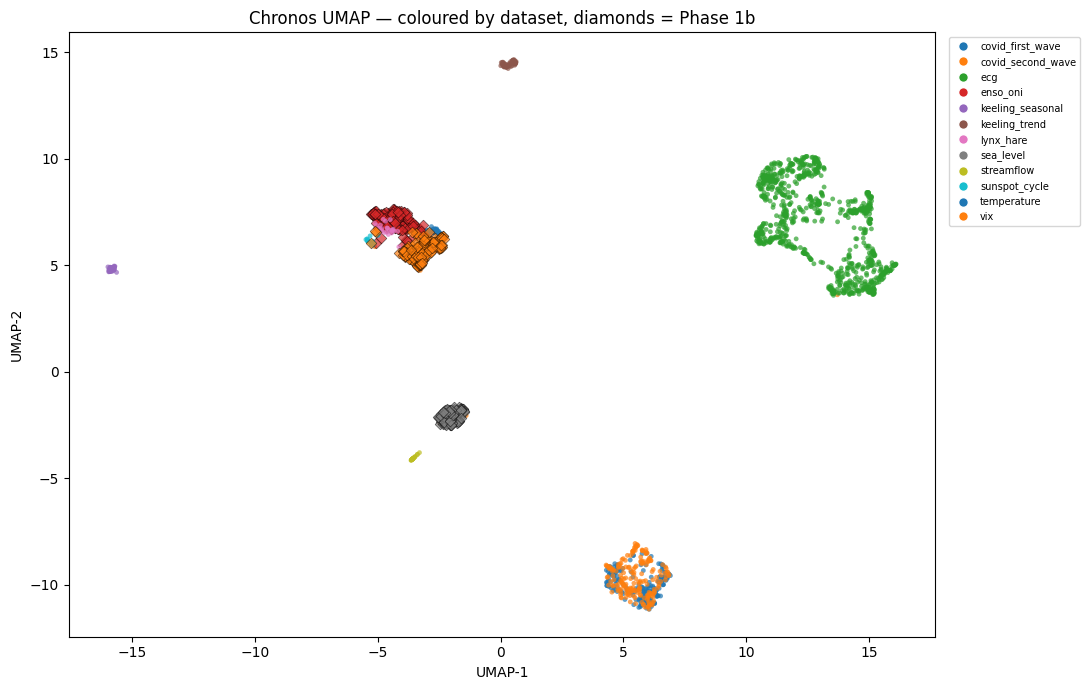

In [20]:
# ============================================================
# HDBSCAN on Chronos embeddings
# Does the foundation model spontaneously recover our taxonomy?
# ============================================================
cl_chronos = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(Z_chronos)
n_cl = len(set(cl_chronos)) - (1 if -1 in cl_chronos else 0)
noise = (cl_chronos == -1).sum()

print(f'Chronos HDBSCAN: {n_cl} clusters, {noise} noise points ({100*noise/len(cl_chronos):.1f}%)')
print()

# Per-dataset distribution across clusters
print(f'{"Dataset":25s}', end='')
for c in sorted(set(cl_chronos)): print(f'  cl{c:2d}', end='')
print()
for ds in DATASETS:
    mask = ds_labels == ds
    total = mask.sum()
    print(f'{ds:25s}', end='')
    for c in sorted(set(cl_chronos)):
        frac = (cl_chronos[mask] == c).sum() / total if total > 0 else 0
        print(f'  {frac:4.2f}', end='')
    print(f'  (n={total})')

fig, ax = plt.subplots(figsize=(11, 7))
for ds in DATASETS:
    mask = ds_labels == ds
    marker = 'D' if ds in PHASE1B else 'o'
    ax.scatter(emb_ch[mask,0], emb_ch[mask,1], c=[ds_color[ds]], s=12 if marker=='o' else 30,
               alpha=0.7, label=ds, marker=marker, edgecolors='k' if marker=='D' else 'none',
               linewidths=0.4)

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=ds_color[ds],
                       markersize=7, label=ds) for ds in DATASETS]
ax.legend(handles=handles, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
ax.set_title('Chronos UMAP — coloured by dataset, diamonds = Phase 1b')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.show()

## Findings — Phase 2b Chronos Foundation Model (nb20)

### Finding 43: Chronos confirms sunspot-COVID as the maximally separated pair — three independent methods agree

Sunspot vs COVID first wave is the farthest centroid pair in Chronos embedding space (0.301), ahead of keeling_seasonal vs keeling_trend (0.225). Hand-crafted features placed them near each other (1.988 raw TD-6f); the Conv AE pushed them apart 5.79x. Chronos — without training on this corpus, without feature engineering — independently places them at maximum separation. Three measurement systems (TD-6f, trained Conv AE, zero-shot Chronos) agree: the 11-year solar cycle and the epidemic burst are the most different shape classes in this corpus.

---

### Finding 44: Chronos separates sea_level from temperature — diverges from Conv AE, 8th class needs refinement

The Conv AE contracted temperature-sea_level (0.17x: from 4.607 feature-space distance to 0.777 latent). Chronos disagrees: sea_level forms its own pure cluster cl3 (97%), while temperature is 77% noise and 23% in the irregular cl6 cluster. Chronos pairwise distance temperature-sea_level = 0.140. The Conv AE saw both as "noisy directional upward drift"; Chronos distinguishes smooth satellite altimetry trend (sea_level) from the noisier temperature record with decadal oscillations. Two independent learned embeddings give different answers — the proposed 8th class may need to be split: clean monotonic trend vs noisy trend.

---

### Finding 45: Chronos discovers a cross-domain irregular cluster — VIX + ENSO + temperature (cl6)

Cluster cl6 contains: VIX (28%), ENSO ONI (24%), temperature (23%) — three datasets from finance, climate oscillation, and global surface temperature. No domain connection. This is a genuine cross-domain shape match discovered zero-shot. The VIX-lynx_hare match from nb17 does not survive into Chronos space: VIX lands in cl6, lynx_hare is 100% noise. Cross-domain groupings are measurement-frame-dependent: ecology-finance in TD features; finance-climate-oscillation in Chronos space.

---

### Finding 46: ECG sub-structure aligns with UCR true labels at ARI=0.742 — Chronos recovers class structure zero-shot

Chronos HDBSCAN on ECG yields 3 sub-clusters with non-noise instances matching UCR labels at ARI=0.742. ECG is 99% pure in cluster cl2. The fragmentation nb18 found (ECG breaks under parameter variation) has real label-aligned structure. A foundation model trained on millions of unrelated series can discriminate ECG morphology classes without supervision. Highest ARI of any sub-cluster analysis in this experiment.
